## Exercise E3
### Mapping in Cartopy
#### Tatjana Noah Steixner

This notebook uses python-based cartopy and geopy modules to produce the following maps:

* The Antarctic continent and the Southern Ocean starting from 60°S
* The South Atlantic, from 20°S to 50°S, showing the following locations: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo.

Details on the use of cartopy and geopy features to create the maps are provided:


In [ ]:
#Load the needed modules. Besides cartopy and geopy (for import of location names and coordinates), matplotlib is required for the creation of GeoAxes objects
import cartopy.crs as ccrs #cartopy coordinate reference features
import cartopy.feature as cfeature #cartopy features
from geopy.geocoders import Nominatim #geocoder for lookup of city coordinates
import cartopy.io.shapereader as shpreader #import of bathymetry files
import matplotlib.pyplot as plt #for plotting
import matplotlib #additional features also needed
import numpy as np #general transformations

### Antarctica and Southern Ocean

To create the map of Antarctica and the Southern Ocean, a polar Azimthubal projection is used, in order to most clearly represent the polar region, which in other projections will be distorted. A Azimthubal projection will show the poles as viewed from a plane forming a tangent to the South Pole, with the meridians represented as stright lines radiating from the poles, and lines of latitude being transformed to a circular geometry.
The figure is initialised with the appropriate SouthPolarStereo crs, yet the extent is set using a Plate Carre crs, as this is the only crs which interprets numerical input as coordinates.
Coastline and ocean features are added with the appropriate cfeature calls and points of note are added using Nominatim.  
This includes South Africa's SANAE IV station, McMurdo Station, as well as the South Pole. 

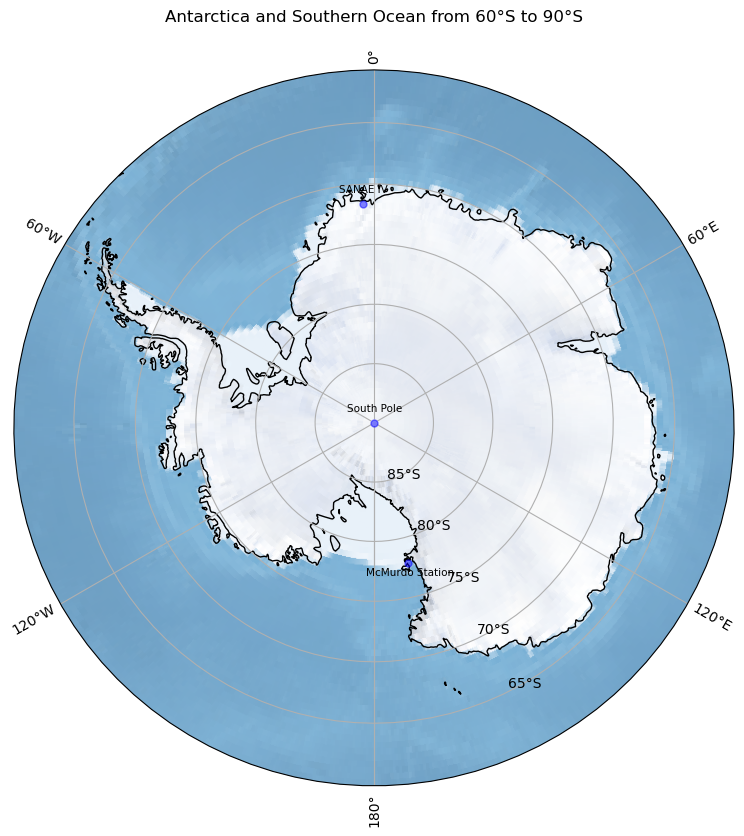

In [ ]:
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': ccrs.SouthPolarStereo()}) #initiate GeoAxes object by specifying crs in dict
#to map Antarctica, a South Polar Azimthubal projection is needed, as specified by the ccrs.SouthPolarStereo() call

#set extent using Plate Carree projection
#this is the only crs where input is interpreted in degrees of latitude/longitude
#setting using ccrs.SouthPolarStereo would result in meters from the pole, which requires transformation
ax.set_extent([-180, 180, -60, -90], crs=ccrs.PlateCarree()) 

#add coastlines, ocean, and gridlines
ax.coastlines() #add coastlines
ax.stock_img() #coarse resolution naturalEarth image of continent/ocean
#coarse resolution evident in sea ice extent, which extends beyond the continental boundaries indicated
ax.add_feature(cfeature.OCEAN) #add ocean feature
ax.gridlines(draw_labels=True) #add gridlines and labels

#initiate geolocator to add points of interests
geolocator = Nominatim(user_agent='educational')

locs = ['SANAE IV','McMurdo Station','South Pole']

#use loop as in tutorial to access geocodes using Nominatim
#append to coords list as dict with name, latitude and longitude
#loop to plot locations and text
coords = []
for loc in locs:
    location = geolocator.geocode(loc, language="en")
    coords.append({'name': loc,'lat': location.latitude,'lon': location.longitude})

for loc in coords:
    ax.plot(loc['lon'], loc['lat'],marker='o', markersize=5, color='b', alpha=0.5,transform=ccrs.PlateCarree())
    ax.text(loc['lon'], loc['lat'] + 1,loc['name'], fontsize=7.5,transform=ccrs.PlateCarree(),ha='center')

#solution generated from prompt as specified in bibliography 
theta = np.linspace(0, 2 * np.pi, 100) #generate sequence from 0 to 2*pi
center, radius = [0.5, 0.5], 0.5 #define center and radius
verts = np.vstack([np.sin(theta), np.cos(theta)]).T #create array of points tracing unit circle, transpose
circle = matplotlib.path.Path(verts * radius + center) #scale and shift
ax.set_boundary(circle, transform=ax.transAxes) #set boundary of axes object using circle defined

ax.set_title("Antarctica and Southern Ocean from 60°S to 90°S\n") #set title
plt.tight_layout(pad=3.0) #add padding

plt.show()

### The South Atlantic  

The representation of the South Atlantic Ocean from 20°S to 50°S including points of interest is initialised using a Plate Carree projection with an offset center to more accurately display the given section.  
In contrast to a Mercator projection, a Plate Carrée projection will more accurately represent the shape and geometry of features when approaching the Poles.  
The representation is clipped to an extent of [-70, -35, -15, 50] to accomodate points of interest.  
Points of interest are added as previously with appropriate calls to Nominatim, with coastline, ocean and country boundaries as cartopy features.  

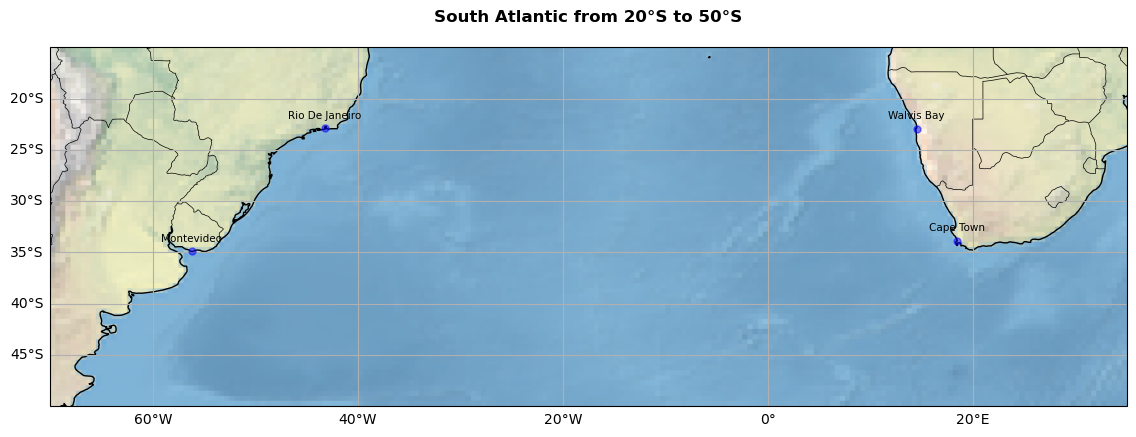

In [65]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=20)}) #initiate GeoAxes object using standard Plate Carree crs

#set extent using Plate Carree crs, crop to 15°S to add space above POIs
ax.set_extent([-70, 35, -15, -50], crs=ccrs.PlateCarree()) 

#as previously, add coastlines, ocean, borders and gridlines
ax.coastlines(resolution='50m') #finer resolution
ax.stock_img() 
ax.add_feature(cfeature.OCEAN) 
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
gl = ax.gridlines(draw_labels=True) 
gl.top_labels = False #remove top and right labels
gl.right_labels = False  

#initiate geolocator to add points of interests
geolocator = Nominatim(user_agent='educational')

locs = ['Cape Town','Walvis Bay','Rio De Janeiro','Montevideo']

#as previously use loop to create dict of POIs including name, latitude and longitude
#second loop will plot points and add text annotation
coords = []
for loc in locs:
    location = geolocator.geocode(loc, language="en")
    coords.append({'name': loc,'lat': location.latitude,'lon': location.longitude})

for loc in coords:
    ax.plot(loc['lon'], loc['lat'],marker='o', markersize=5, color='b', alpha=0.5,transform=ccrs.PlateCarree())
    ax.text(loc['lon'], loc['lat'] + 1,loc['name'], fontsize=7.5,transform=ccrs.PlateCarree(),ha='center')

ax.set_title("South Atlantic from 20°S to 50°S\n", fontweight='bold') #set title
plt.tight_layout(pad=3.0) #add padding

plt.show()

Adding high-resolution bathymetric features using cartopy docs was attempted but unsucessful.  


#### Bibliography 

Anthropic. 2026. "Azimuthal Polar Projection in Cartopy Using subplot_kw." Response generated by Claude Sonnet 4.6 in response to the prompt: "Let me know how to access an azimuthal polar projection to plot using cartopy…" Accessed May 6, 2026. https://claude.ai.  

Hunter, J. D. “Matplotlib: A 2D Graphics Environment.” Computing in Science & Engineering 9, no. 3 (2007): 90–95. https://doi.org/10.1109/MCSE.2007.55.  

Met Office. Cartopy: A Cartographic Python Library with a Matplotlib Interface. Exeter, Devon, 2010. https://cartopy.readthedocs.io.  

South, Andy, Schramm Michael, and Philippe Massicotte. Rnaturalearthdata: World Vector Map Data from Natural Earth Used in “Rnaturalearth.” 2026. https://docs.ropensci.org/rnaturalearthdata/.

